# Análise PCA e MDS com dados da ANP

Este notebook registra o caminho usado pelo grupo para estudar a relação entre preço da gasolina C, volume vendido e participação do etanol hidratado. A ideia é manter a análise próxima do problema do projeto: uma rede de postos ou distribuidora precisa entender melhor diferenças regionais antes de decidir estoque, mix comercial e campanhas.

In [1]:
import sys
from pathlib import Path
sys.path.append(str(Path('..').resolve()))
import matplotlib.pyplot as plt
import pandas as pd
from src.data_preparation import FEATURES_NUMERICAS, padronizar_features, preparar_dados
from src.pca_analysis import aplicar_pca
from src.mds_analysis import aplicar_mds

## Preparação dos dados

As bases da ANP vêm separadas: uma traz preços médios por estado e outra traz volumes vendidos por produto. Nesta etapa, os nomes de estados são normalizados, gasolina C e etanol hidratado são selecionados, as bases são cruzadas por mês e UF, e novas variáveis são calculadas para comparar preço, volume e participação do etanol.

In [2]:
dados = preparar_dados(periodo_inicio=2021, periodo_fim=2025)
dados_padronizados, scaler = padronizar_features(dados)
dados.shape, FEATURES_NUMERICAS

((1379, 16),
 ['preco_medio_gasolina_c',
  'volume_gasolina_c_m3',
  'volume_etanol_hidratado_m3',
  'variacao_preco_gasolina_c',
  'variacao_volume_gasolina_c',
  'participacao_etanol',
  'razao_etanol_gasolina',
  'preco_relativo_etanol_gasolina'])

## Conferência inicial

Antes de aplicar PCA e MDS, vale olhar algumas linhas do dataset tratado. Cada registro representa uma combinação de mês e UF. As colunas de variação ajudam a observar mudanças mensais, enquanto participação e razão do etanol mostram o peso do combustível substituto.

In [3]:
dados[['mes_ano', 'uf', 'regiao', 'preco_medio_gasolina_c', 'volume_gasolina_c_m3', 'volume_etanol_hidratado_m3', 'participacao_etanol']].head()

produto_final,mes_ano,uf,regiao,preco_medio_gasolina_c,volume_gasolina_c_m3,volume_etanol_hidratado_m3,participacao_etanol
0,2021-01-01,AC,NORTE,5.229,10958.7,682.353,0.058616
1,2021-02-01,AC,NORTE,5.520,9112.5,688.676,0.070265
2,2021-03-01,AC,NORTE,6.121,10632.7,783.804,0.068655
3,2021-04-01,AC,NORTE,6.228,10251.0,661.899,0.060653
4,2021-05-01,AC,NORTE,6.319,11422.6,662.783,0.054842


## Padronização

A padronização evita que variáveis de volume, que têm valores muito maiores, dominem a análise. Depois desse passo, cada feature numérica passa a ser comparada em uma escala comum.

In [4]:
dados_padronizados.describe().round(3)

,preco_medio_gasolina_c,volume_gasolina_c_m3,volume_etanol_hidratado_m3,variacao_preco_gasolina_c,variacao_volume_gasolina_c,participacao_etanol,razao_etanol_gasolina,preco_relativo_etanol_gasolina
count,1379.000,1379.000,1379.000,1379.000,1379.000,1379.000,1379.000,1379.000
mean,0.000,0.000,-0.000,0.000,-0.000,-0.000,-0.000,-0.000
std,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000
min,-2.629,-0.777,-0.352,-5.123,-4.181,-1.141,-0.843,-2.366
25%,-0.677,-0.603,-0.332,-0.336,-0.637,-0.735,-0.613,-0.689
50%,-0.013,-0.364,-0.309,-0.070,-0.008,-0.292,-0.334,-0.159
75%,0.573,0.309,-0.208,0.471,0.617,0.440,0.205,0.515
max,3.128,5.091,5.685,3.628,3.527,3.909,5.854,4.418


## PCA

O PCA cria novas dimensões que concentram a variação dos dados. Aqui usamos duas componentes para visualizar os registros em um plano. Também analisamos as cargas de cada variável, pois elas indicam quais features mais pesam em cada componente.

In [5]:
pca_df, cargas, variancia, pca = aplicar_pca(dados_padronizados)
display(variancia)
display(cargas.sort_values('PC1', key=abs, ascending=False))

,componente,variancia_explicada,variancia_acumulada
0,PC1,0.474991,0.474991
1,PC2,0.162894,0.637885


,PC1,PC2
razao_etanol_gasolina,0.499545,0.012824
participacao_etanol,0.484931,0.076243
volume_etanol_hidratado_m3,0.470912,-0.150882
volume_gasolina_c_m3,0.437644,-0.219432
preco_relativo_etanol_gasolina,-0.317840,-0.330698
variacao_preco_gasolina_c,0.030021,0.622986
preco_medio_gasolina_c,-0.007182,0.405846
variacao_volume_gasolina_c,-0.005501,-0.510807


## Gráfico do PCA

No gráfico, cada ponto é um registro UF-mês. A cor por região ajuda a perceber se há separação regional. Pontos muito afastados merecem atenção porque podem representar mercados de escala diferente, maior participação do etanol ou meses com mudança brusca.

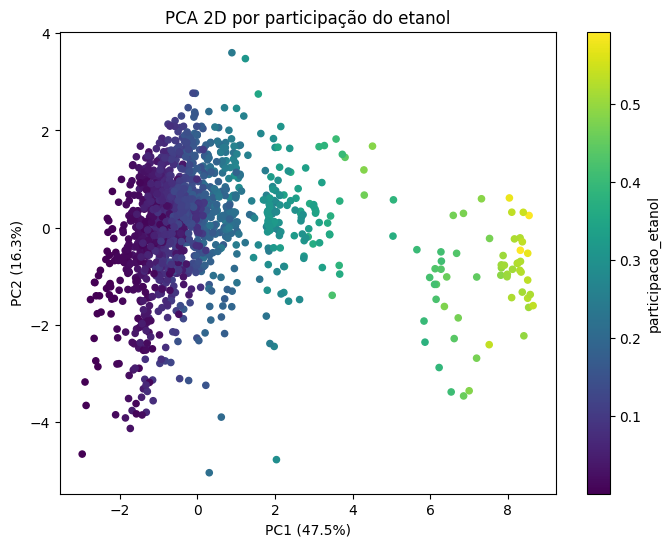

In [6]:
pca_plot = dados.join(pca_df)
ax = pca_plot.plot.scatter(x='PC1', y='PC2', c='participacao_etanol', colormap='viridis', figsize=(8, 6))
ax.set_title('PCA 2D por participação do etanol')
ax.set_xlabel(f"PC1 ({variancia.loc[0, 'variancia_explicada']:.1%})")
ax.set_ylabel(f"PC2 ({variancia.loc[1, 'variancia_explicada']:.1%})")
plt.show()

## MDS

O MDS parte das distâncias entre registros. Ele não mostra diretamente quais variáveis explicam os eixos, mas ajuda a enxergar quais meses e estados ficaram próximos no perfil geral de preço, volume e participação do etanol.

In [7]:
mds_df, mds = aplicar_mds(dados_padronizados, max_registros=800)
print(f'Stress MDS: {mds.stress_:.2f}')
mds_df.head()

Stress MDS: 179725.65


,MDS1,MDS2
599,-2.813245,0.609522
881,0.061762,2.224749
634,1.166169,0.985876
425,0.873574,-1.793692
906,0.204466,-2.048508


## Gráfico do MDS

Nesta visualização, pontos próximos indicam registros com comportamento parecido nas features padronizadas. A leitura deve ser feita com cuidado, pois a projeção em duas dimensões simplifica relações que originalmente estão em mais variáveis.

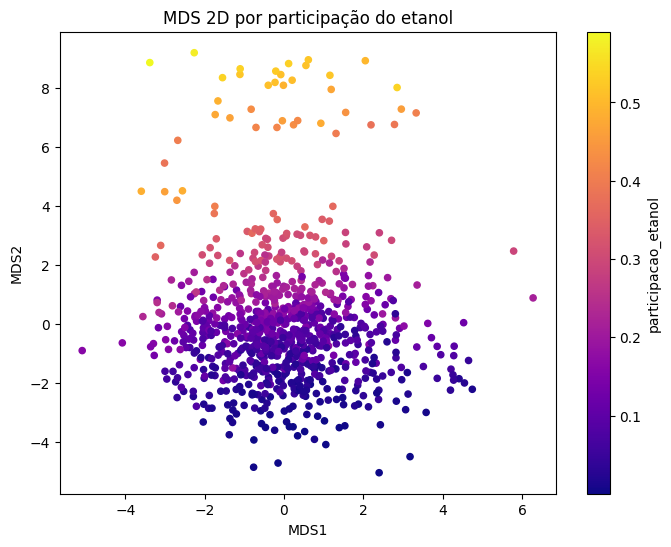

In [8]:
mds_plot = dados.loc[mds_df.index].join(mds_df)
ax = mds_plot.plot.scatter(x='MDS1', y='MDS2', c='participacao_etanol', colormap='plasma', figsize=(8, 6))
ax.set_title('MDS 2D por participação do etanol')
ax.set_xlabel('MDS1')
ax.set_ylabel('MDS2')
plt.show()

## Leitura final

O PCA foi mais útil para explicar a influência das variáveis. O MDS complementou a análise ao mostrar proximidade entre registros. Em conjunto, os dois métodos indicam que o comportamento do mercado depende de preço, escala de vendas e presença do etanol, não apenas de uma variável isolada.